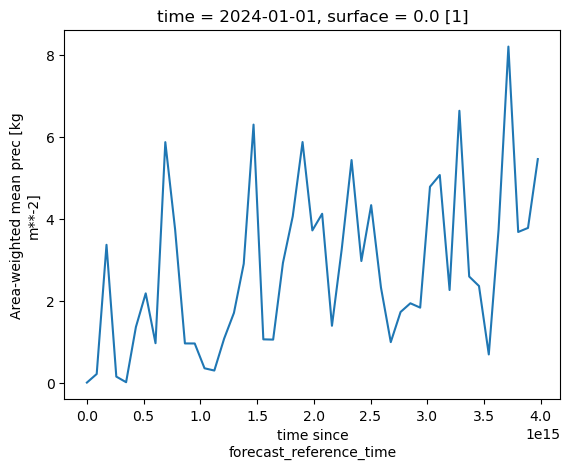

In [ ]:
from pyenspp.utils import conform_obs, conform_forecast, cum_to_step, area_mean_precip
import geopandas as gpd
from pathlib import Path
import xarray as xr
import os
import matplotlib.pyplot as plt

current_dir = Path().resolve()  # get current directory
parent_dir = current_dir

# get the path of the example data
data_path = parent_dir / "data"
# get the ensemble precipitation forecast
fcst_data_path = os.path.join(data_path,  "example_fcst.grib")
fcst_ds = xr.open_dataset(fcst_data_path)
fcst_ds = conform_forecast(fcst_ds)
# get the observational precipitation
obs_data_path = os.path.join(data_path,  "chirps.nc")
obs_ds = xr.open_dataset(obs_data_path)

shp_path = os.path.join(data_path, "shp")
region = gpd.read_file(shp_path)
fcst_area = area_mean_precip(fcst_ds, region)

# convert the cum_prec to step_prec
fcst_area_step = cum_to_step(fcst_area, var_name='prec')

fcst_area_step.sel(time='2024-01-01').mean(dim='number').plot()

In [ ]:
from pyenspp.verification import EnsembleEvaluator

example_ens = fcst_area_step.sel(step='1 days').transpose('time','number').values
example_obs = obs_ds.sel(time=fcst_area_step.sel(step='1 days').time).prec.values

evaluator = EnsembleEvaluator(example_obs, example_ens)
print('CRPS value is:', evaluator.crps())
print('Mean BIAS value is:', evaluator.mb())
print('pit value is:', evaluator.pit())
print('alpha-index values is:', evaluator.alpha_index())

CRPS value is: [2.51240745e-05 1.03766193e-02 1.09039045e+00 0.00000000e+00
 0.00000000e+00 4.28027833e+00 0.00000000e+00 5.30645437e-02
 4.24164493e-03 1.03385955e-01 0.00000000e+00 8.31204874e-03
 2.29716753e+00 7.41160197e-04 1.23175968e-01 3.34696755e-04
 7.46362925e-01 1.63477993e-01 6.61485960e-01 2.70613178e+00]
BIAS value is: -0.11019945313090777
pit value is: [0.77395605 0.30721491 0.9        0.69736803 0.09417735 0.
 0.7611397  0.         0.08967954 1.         0.37079802 1.
 1.         0.74048545 0.3        0.20451485 1.         1.
 1.         1.        ]
alpha-index values is: 0.7036292583733563
